In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load Dataset

df = pd.read_csv("creditcard.csv")

In [3]:
df.shape

(284807, 31)

In [4]:
# 3 EDA + Data Cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1081)


= CLASS DISTRIBUTION 
Class
0    284315
1       492
Name: count, dtype: int64


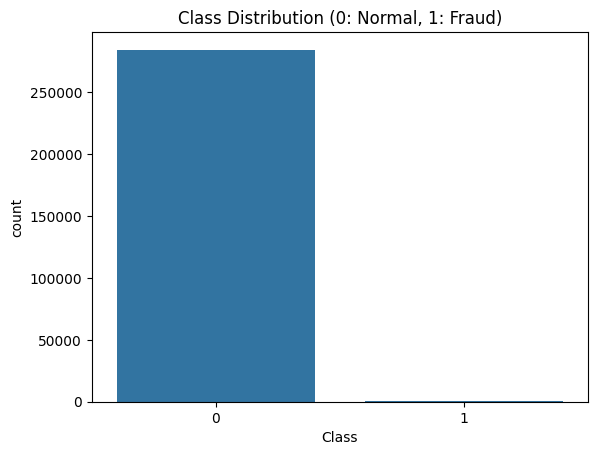

In [7]:
# Class Distribution
print("\n= CLASS DISTRIBUTION ")
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0: Normal, 1: Fraud)")
plt.show()

In [8]:
# 3. Feature Engineering
df['Amount_log'] = np.log1p(df['Amount'])
df['Amount_Category'] = pd.qcut(df['Amount'], q=4, labels=False)

In [9]:
# 4. Prepare Data
X = df.drop("Class", axis=1)
y = df["Class"]

In [10]:
scaler = StandardScaler()
X[['Amount', 'Time', 'Amount_log']] = scaler.fit_transform(X[['Amount', 'Time', 'Amount_log']])


In [11]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:\n", y_train.value_counts())


Before SMOTE:
 Class
0    227451
1       394
Name: count, dtype: int64


In [12]:
# 6. Handle Class Imbalance (SMOTE)
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_train_sm).value_counts())

After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


In [13]:
# 7. Model Training

In [14]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [15]:
# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_sm, y_train_sm)

c:\Data Analyst\Python\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:47:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
# 8. Evaluation Function
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



===== Random Forest =====
Accuracy: 0.9995259997893332
Precision: 0.8817204301075269
Recall: 0.8367346938775511
F1 Score: 0.8586387434554974
ROC-AUC: 0.9743054139917081

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



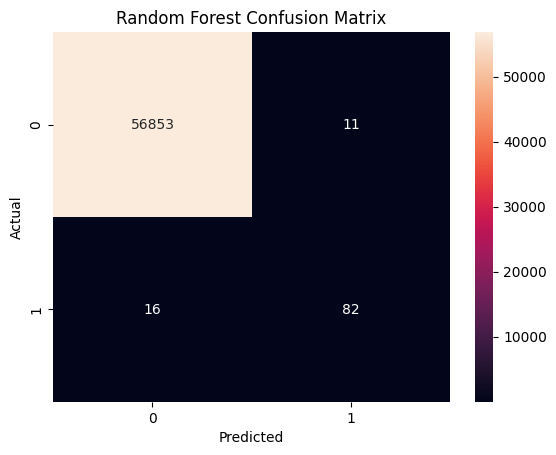


===== XGBoost =====
Accuracy: 0.9992977774656788
Precision: 0.7636363636363637
Recall: 0.8571428571428571
F1 Score: 0.8076923076923077
ROC-AUC: 0.9752127884074282

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.86      0.81        98

    accuracy                           1.00     56962
   macro avg       0.88      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



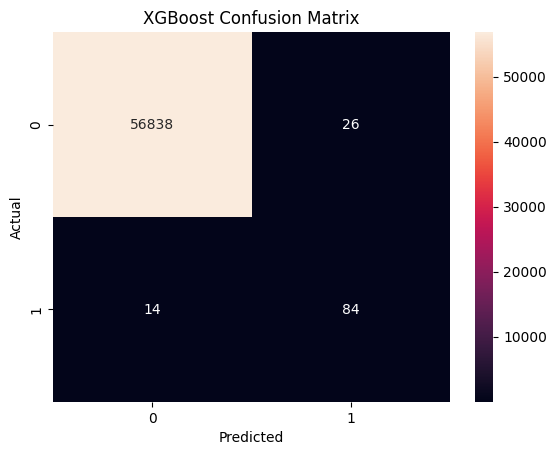

In [17]:
# 9. Evaluate Models
evaluate_model(rf_model, X_test, y_test, "Random Forest")
evaluate_model(xgb_model, X_test, y_test, "XGBoost")


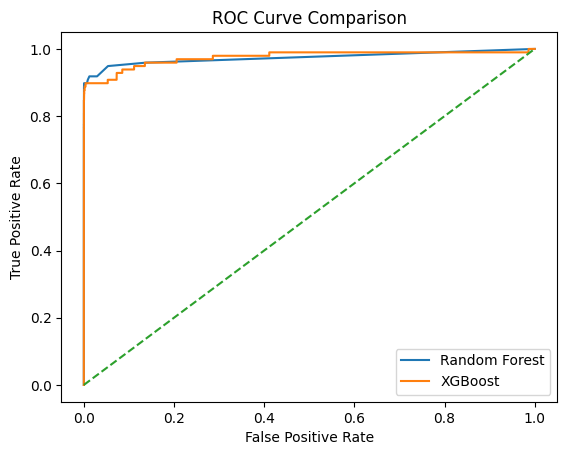

In [20]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

rf_prob = rf_model.predict_proba(X_test)[:,1]
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [22]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved successfully ")

Saved successfully 


In [23]:
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']